Erreur L2 : 0.005432187128587901
Erreur relative L2 : 7.682657813376189e-05
Erreur L∞ : 0.007697026796416183


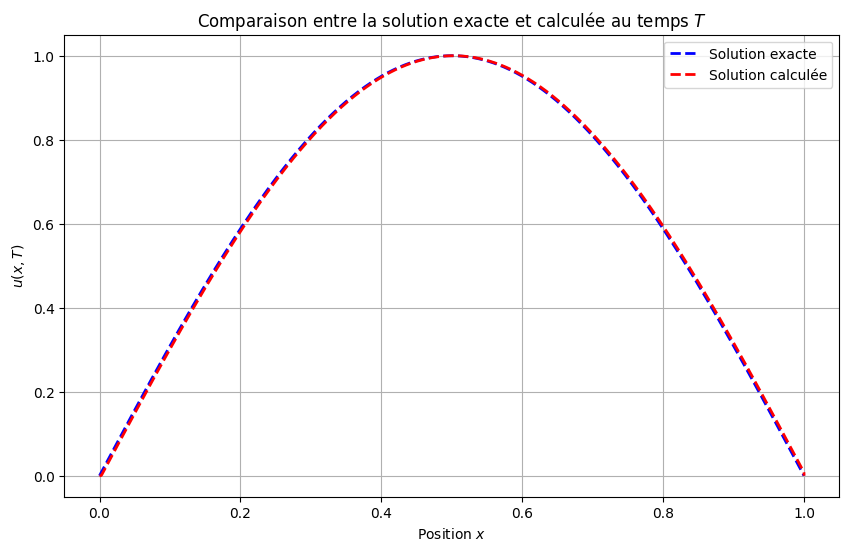

In [2]:
import numpy as np
import matplotlib.pyplot as plt

#Paramètres

C = 1.0 #Coeff de convection
D = 1.0 #Coef de diffusion
L = 1.0 #Taille du domaine spatial
Nx = 10000 #Nombre de points spatiaux
Nt = 50 #Nombre de points temporels

dx = L/Nx #Pas spatial

gamma = 1/4
v = 1/2

dt1 = gamma*(dx**2)/D
dt2 = v*dx/C

dt = min(dt1,dt2)
T=Nt*dt


def u_exacte(x,t):
  return np.sin(np.pi*x)*np.exp(-t)

#Fonction source
def f(x, t):
    return -np.sin(np.pi*x)*np.exp(-t)+D*((np.pi**2)*np.sin(np.pi*x)*np.exp(-t))+C*(np.pi*np.cos(np.pi*x)*np.exp(-t))

# Initialisation des grilles
x = np.linspace(0, L, Nx)
t = np.linspace(0, T, Nt)
u_calculé = np.zeros((Nx, Nt))

#Condition initiale
u_calculé[:, 0] = u_exacte(x, 0)

for n in range(Nt-1) :
  for i in range(1, Nx-1) :
    if C>0:
      du=u_calculé[i,n] - u_calculé[i-1,n]
    else:
      du=u_calculé[i+1,n] - u_calculé[i,n]
    u_calculé[i, n+1] = u_calculé[i, n] + gamma * (u_calculé[i+1, n] - 2*u_calculé[i, n] + u_calculé[i-1, n]) - v*du + f(x[i], t[n])*dt

  # Conditions aux limites
  u_calculé[0, n+1] = 0
  u_calculé[-1, n+1] = 0


erreur = np.abs(u_calculé[:, -1] - u_exacte(x, T))

# Normes
def norme_L2(erreur):
    return np.sqrt(dx * np.sum(erreur**2))

def norme_Linf(erreur):
    return np.max(np.abs(erreur))

print("Erreur L2 :", norme_L2(erreur))
print("Erreur relative L2 :", norme_L2(erreur)/ np.linalg.norm(u_exacte(x, T)))
print("Erreur L∞ :", norme_Linf(erreur))

# Visualisation des résultats
X, Time = np.meshgrid(x, t)
"""plt.figure(figsize=(8, 6))
plt.contourf(X, Time, u_calculé.T, 20, cmap='hot')
plt.colorbar(label='Concentration u')
plt.xlabel('Position $x$')
plt.ylabel('Temps $t$')
plt.title('Évolution de u(x,t) avec un schéma explicite')
plt.show()

# Visualisation des erreurs
plt.figure(figsize=(10, 6))
plt.plot(x, erreur, label="Erreur au dernier instant $T$")
plt.xlabel("Position $x$")
plt.ylabel("Erreur $u_{calculé} - u_{exact}$")
plt.title("Erreur entre la solution calculée et exacte")
plt.legend()
plt.grid()
plt.show()"""

# Créer la grille spatiale et temporelle
X, Time = np.meshgrid(x, t, indexing='ij')  # Grille compatible avec u_calculé

# Calculer l'erreur absolue point par point
erreur_absolue = np.abs(u_calculé - u_exacte(X, Time))

# Visualiser l'erreur
"""plt.figure(figsize=(10, 6))
plt.contourf(X, Time, erreur_absolue, 20, cmap='coolwarm')
plt.colorbar(label='Erreur absolue')
plt.xlabel('Position $x$')
plt.ylabel('Temps $t$')
plt.title('Erreur absolue sur tout le domaine $(x, t)$')
plt.show()"""

# Tracer les solutions exacte et calculée à t = T (dernier instant)
plt.figure(figsize=(10, 6))
plt.plot(x, u_exacte(x, T), label="Solution exacte", color="blue", linestyle="--", linewidth=2)
plt.plot(x, u_calculé[:, -1], label="Solution calculée", color="red", linestyle="--", linewidth=2)

# Ajouter des détails au graphique
plt.xlabel('Position $x$')
plt.ylabel('$u(x, T)$')
plt.title('Comparaison entre la solution exacte et calculée au temps $T$')
plt.legend()
plt.grid(True)

plt.savefig('Comparaison_solution_exacte_calculée_cas2.png')
plt.show()